# **EDA previo a la limpieza**

In [1]:
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

RUTA_CRUDA = "../data/raw/train.csv"
df = pd.read_csv(RUTA_CRUDA, dtype=str)

print(f"Filas:    {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head(5)

Filas:    7,613
Columnas: 5


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## **1. Las 5 variables: descripcion y tipo**
| Variable | Tipo | Descripcion |
|---|---|---|
| id | Cualitativa categorica (nominal) | Identificador unico del tweet. Aunque se almacena como numero, no mide nada: promediarlo o compararlo no significa nada. Solo sirve para trazar cada fila. |
| keyword | Cualitativa categorica (nominal) | Palabra clave asociada al tweet, como ablaze o wreckage. Tiene 221 categorias. Viene codificada como URL: los espacios aparecen como %20. |
| location | Cualitativa categorica (nominal) | Ubicacion declarada por el usuario. Es campo libre sin validar, asi que mezcla paises, ciudades, bromas y basura. Un tercio esta vacio. |
| text | Cualitativa (nominal, texto libre) | El texto del tweet. No es categorica en sentido estricto: casi todos los valores son unicos. Es la fuente de senal del problema. |
| target | Cualitativa categorica (nominal dicotomica) | Etiqueta de clasificacion. Vale 1 si el tweet habla de un desastre real y 0 si no. |

Las celdas siguientes verifican cada afirmacion de esta tabla.

In [2]:
resumen = pd.DataFrame({
    "nulos":   df.isna().sum(),
    "unicos":  df.nunique(),
    "ejemplo": [df[c].dropna().iloc[0][:60] for c in df.columns],
})
resumen

,nulos,unicos,ejemplo
id,0,7613,1
keyword,61,221,ablaze
location,2533,3341,Birmingham
text,0,7503,Our Deeds are the Reason of this #earthquake May ALLAH Forgi
target,0,2,1


Lo que muestra la tabla:

- id, text y target no tienen faltantes. No hay que descartar filas por falta de etiqueta.
- keyword tiene 61 faltantes sobre 7,613 filas: practicamente nada.
- **location tiene 2,533 faltantes, un tercio del dataset.** Es el problema mas grande de nulos.
- text tiene 7,503 valores unicos sobre 7,613 filas: **hay tweets repetidos**. Se revisa en 2.5.

Distribucion de la variable objetivo:
  target=0 (no desastre   ): 4,342 tweets  (57.03%)
  target=1 (desastre real ): 3,271 tweets  (42.97%)


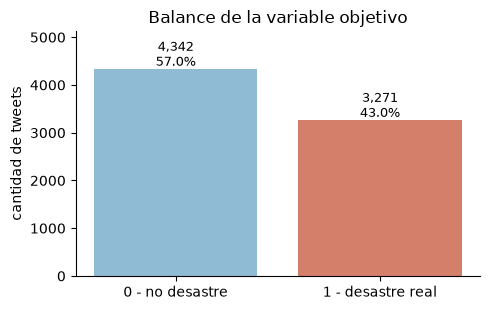

In [3]:
# Variable objetivo: balance de clases.
conteo = df["target"].value_counts().sort_index()
prop = df["target"].value_counts(normalize=True).sort_index()

print("Distribucion de la variable objetivo:")
for k in conteo.index:
    etiqueta = "desastre real" if k == "1" else "no desastre"
    print(f"  target={k} ({etiqueta:14s}): {conteo[k]:5,d} tweets  ({prop[k]*100:5.2f}%)")

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(["0 - no desastre", "1 - desastre real"], conteo.values, color=["#8fbcd4", "#d47f6a"])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 60, f"{v:,}\n{prop.iloc[i]*100:.1f}%", ha="center", fontsize=9)
ax.set_ylabel("cantidad de tweets")
ax.set_title("Balance de la variable objetivo")
ax.set_ylim(0, conteo.max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

El desbalance es leve (57% / 43%). Aunque no sea mucha la diferencia, esto implica que no se puede utilizar solo accuracy como métrica guía al evaluar la calidad de los modelos.


## **2. Revision variable por variable**
### **2.1 id**

In [4]:
print("ids duplicados:", df["id"].duplicated().sum())
print("ids son enteros:", df["id"].str.fullmatch(r"\d+").all())
print("rango:", df["id"].astype(int).min(), "-", df["id"].astype(int).max())
print("cantidad de filas:", len(df))

ids duplicados: 0
ids son enteros: True
rango: 1 - 10873
cantidad de filas: 7613


`id` es unico y entero, pero **no es correlativo** (el maximo supera la cantidad de filas: hay huecos,
porque Kaggle repartio los ids entre train y test). Dado que solo es un identificador no se tomará en cuenta para el modelo.

### **2.2 keyword**

In [5]:
kw = df["keyword"]
print(f"faltantes: {kw.isna().sum()} ({kw.isna().mean()*100:.2f}%)")
print(f"valores unicos: {kw.nunique()}")
print(f"\nvalores con codificacion URL '%20': {kw.str.contains('%20', na=False).sum()} filas")
print("ejemplos afectados:", [v for v in kw.dropna().unique() if "%20" in v][:6])
print("\nprimeras 15 keywords:", sorted(kw.dropna().unique())[:15])

faltantes: 61 (0.80%)
valores unicos: 221

valores con codificacion URL '%20': 1165 filas
ejemplos afectados: ['airplane%20accident', 'blew%20up', 'blown%20up', 'body%20bag', 'body%20bagging', 'body%20bags']

primeras 15 keywords: ['ablaze', 'accident', 'aftershock', 'airplane%20accident', 'ambulance', 'annihilated', 'annihilation', 'apocalypse', 'armageddon', 'army', 'arson', 'arsonist', 'attack', 'attacked', 'avalanche']


In [6]:
df["target_i"] = df["target"].astype(int)
tasa = (df.dropna(subset=["keyword"])
          .groupby("keyword")["target_i"]
          .agg(tasa_desastre="mean", n="count")
          .sort_values("tasa_desastre"))

extremas = ((tasa["tasa_desastre"] < 0.10) | (tasa["tasa_desastre"] > 0.90)).sum()
print(f"keywords con tasa de desastre extrema (<10% o >90%): {extremas} de {len(tasa)}")
print(f"tasa promedio: {tasa['tasa_desastre'].mean():.3f}  |  desviacion: {tasa['tasa_desastre'].std():.3f}\n")

print("--- 8 keywords MAS asociadas a desastre real ---")
print(tasa.tail(8).iloc[::-1].round(3).to_string())
print("\n--- 8 keywords MENOS asociadas a desastre real ---")
print(tasa.head(8).round(3).to_string())

keywords con tasa de desastre extrema (<10% o >90%): 33 de 221
tasa promedio: 0.425  |  desviacion: 0.271

--- 8 keywords MAS asociadas a desastre real ---
                   tasa_desastre   n
keyword                             
derailment                 1.000  39
wreckage                   1.000  39
debris                     1.000  37
outbreak                   0.975  40
typhoon                    0.974  38
oil%20spill                0.974  38
suicide%20bombing          0.970  33
suicide%20bomber           0.968  31

--- 8 keywords MENOS asociadas a desastre real ---
             tasa_desastre   n
keyword                       
aftershock           0.000  34
body%20bags          0.024  41
ruin                 0.027  37
blazing              0.029  34
body%20bag           0.030  33
electrocute          0.031  32
screaming            0.056  36
traumatised          0.057  35


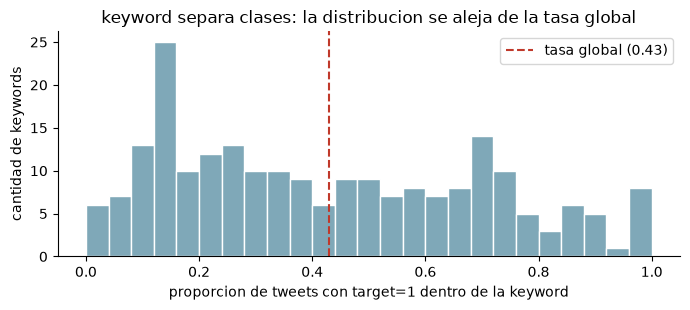

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(tasa["tasa_desastre"], bins=25, color="#7fa8b8", edgecolor="white")
ax.axvline(df["target_i"].mean(), color="#c0392b", ls="--", lw=1.5,
           label=f"tasa global ({df['target_i'].mean():.2f})")
ax.set_xlabel("proporcion de tweets con target=1 dentro de la keyword")
ax.set_ylabel("cantidad de keywords")
ax.set_title("keyword separa clases: la distribucion se aleja de la tasa global")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

La distribución esta muy dispersa (desviación de 0.27 sobre una media de 0.43) y hay
33 keywords de 221 que son casi deterministas, con `debris`, `wreckage` o `derailment` el tweet
es desastre real practicamente siempre; con `aftershock` casi nunca. `keyword` **si aporta senal
y vale la pena conservarla** como predictora, no solo como metadato. Antes hay que decodificar el `%20`
que traen algunas palabras.

### **2.3 location**

In [8]:
loc = df["location"]
print(f"faltantes: {loc.isna().sum():,} ({loc.isna().mean()*100:.2f}%)")
print(f"valores unicos: {loc.nunique():,} sobre {loc.notna().sum():,} valores presentes")
print(f"aparecen una sola vez: {(loc.value_counts() == 1).sum():,} valores\n")

print("--- 10 ubicaciones mas frecuentes ---")
print(loc.value_counts().head(10).to_string())
print("\n--- muestra sin filtrar (evidencia de que es campo libre) ---")
for v in loc.dropna().unique()[48:64]:
    print("   ", repr(v))

faltantes: 2,533 (33.27%)
valores unicos: 3,341 sobre 5,080 valores presentes
aparecen una sola vez: 2,818 valores

--- 10 ubicaciones mas frecuentes ---
location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22

--- muestra sin filtrar (evidencia de que es campo libre) ---
    'Baton Rouge, LA'
    'Hagerstown, MD'
    'Gloucestershire , UK'
    'Nairobi, Kenya'
    'Instagram - @heyimginog '
    '304'
    'Switzerland'
    'US'
    'Somewhere Only We Know ?'
    'Belgium'
    'dope show'
    'Oshawa, Canada'
    'Baker City Oregon'
    'United States'
    'marysville ca '
    'Hermosa Beach, CA'


Tras ver los datos, se llega a la conclusión de que `location` esta inservible tal como viene:

- Un tercio vacio.
- 3,341 valores distintos para 5,080 valores presentes, y la mayoria aparece **una sola vez**, no ayuda a marcar patrones.
- Es campo libre sin validar: conviven `USA`, `US` y `United States` como entradas distintas, junto con
  bromas (`Somewhere Only We Know ?`, `dope show`) y basura (`304`, `Instagram - @heyimginog`).

Se descartará como variable predictora dada esta situación.

### **2.4 text**

In [9]:
t = df["text"]

patrones = {
    "URL (http/https)":      r"https?://\S+",
    "mencion @usuario":      r"@\w+",
    "hashtag #tema":         r"#\w+",
    "entidad HTML (&amp;)":  r"&(?:amp|lt|gt|quot|#\d+);",
    "mojibake (\\x89U...)":   r"\x89",
    "caracter no ASCII":     r"[^\x00-\x7F]",
    "digitos":               r"\d",
    "token '911'":           r"\b911\b",
    "emoji unicode":         "[\U0001F300-\U0001FAFF☀-➿]",
    "retweet 'RT'":          r"^RT\b",
    "salto de linea":        r"[\n\r]",
    "PALABRA EN MAYUSCULAS": r"\b[A-Z]{3,}\b",
    "apostrofe (recto/curvo)": "['‘’´`]",
    "signo de puntuacion":   r"[^\w\s]",
}

filas = []
for nombre, patron in patrones.items():
    n = int(t.str.contains(patron, regex=True, na=False).sum())
    filas.append({"patron": nombre, "tweets": n, "pct": round(n / len(t) * 100, 2)})

ruido = pd.DataFrame(filas).sort_values("tweets", ascending=False).reset_index(drop=True)
ruido

,patron,tweets,pct
0,signo de puntuacion,7277,95.59
1,digitos,4525,59.44
2,URL (http/https),3971,52.16
3,mencion @usuario,2009,26.39
4,apostrofe (recto/curvo),1981,26.02
5,hashtag #tema,1743,22.90
6,PALABRA EN MAYUSCULAS,1487,19.53
7,caracter no ASCII,697,9.16
8,mojibake (\x89U...),614,8.07
9,salto de linea,435,5.71


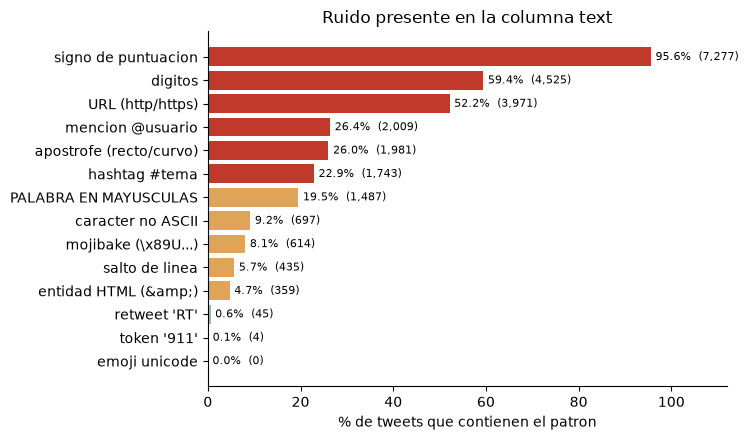

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
d = ruido.sort_values("pct")
colores = ["#c0392b" if p > 20 else "#e0a458" if p > 4 else "#9fb8ad" for p in d["pct"]]
ax.barh(d["patron"], d["pct"], color=colores)
for y, (p, n) in enumerate(zip(d["pct"], d["tweets"])):
    ax.text(p + 1, y, f"{p:.1f}%  ({n:,})", va="center", fontsize=8)
ax.set_xlabel("% de tweets que contienen el patron")
ax.set_title("Ruido presente en la columna text")
ax.set_xlim(0, 112); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Lectura de la tabla de ruido.** Tres grupos, y cada uno se trata distinto:

- **Ruido masivo (>20%):** puntuacion (95.6%), digitos (59.4%), URLs (52.2%), menciones (26.4%),
  apostrofes (26.0%), hashtags (22.9%). Son las tareas de limpieza obligatorias.
- **Ruido moderado (4-20%):** palabras en mayusculas (19.5%), caracteres no ASCII (9.2%),
  mojibake (8.1%), saltos de linea (5.7%), entidades HTML (4.7%).
- **Practicamente inexistente (<1%):** emojis (0%), retweets (0.6%), el token `911` (0.05%).

Cabe mencionar que no se encontraron mensajes con emojis en el dataset. 

In [11]:
# Muestra de tweets crudos: se ve el ruido concentrado en casos reales.
muestra = [31, 120, 600, 1500, 3000, 5000, 7000]
for i in muestra:
    print(f"[target={df.loc[i, 'target']}] {df.loc[i, 'text']!r}\n")

[target=1] '@bbcmtd Wholesale Markets ablaze http://t.co/lHYXEOHY6C'

[target=0] '#WisdomWed BONUS - 5 Minute Daily Habits that could really improve your life. How many do you already do? #lifehacks http://t.co/TBm9FQb8cW'

[target=0] '#BreakingNews http://t.co/gAN14PW9TG FedEx no longer willing to transport research specimens of potential bioter\x89Û_ http://t.co/5n4hUsewLy'

[target=0] 'catastrophic-fallen-angel: reveillertm: macabrelolita: I was supposed to write \x89Û÷amino acids\x89Ûª and I nearly... http://t.co/dIoBzGHFju'

[target=1] "Dust Storm 'en route' from Alice Springs to Uluru http://t.co/4ilt6FXU45"

[target=0] '13 reasons why we love women in the military   - lulgzimbestpicts http://t.co/IAPvTqxLht http://t.co/WAMKRe6CKD'

[target=0] 'HAPPY 24 TWISTER!!! Thank you for all the laughs sticking by my side no matter what and also for\x89Û_ https://t.co/ttq9IlHp8W'



Las secuencias `\x89Û_`, `\x89Ûª`, `\x89ÛÏ` que aparecen en la muestra no son texto: son **mojibake**,
el resultado de haber leido caracteres UTF-8 como si fueran Windows-1252 cuando se armo el dataset.
Corresponden a comillas tipograficas, guiones largos y puntos suspensivos.

In [12]:
moj = t[t.str.contains("\x89", na=False)]
print(f"tweets afectados por mojibake: {len(moj):,} ({len(moj)/len(t)*100:.2f}%)\n")

secuencias = Counter()
for s in moj:
    secuencias.update(re.findall(r"\x89[^\x00-\x7F]*", s))
print("--- secuencias mas frecuentes y su caracter original ---")
equivalencias = {"\x89Û": "?", "\x89Ûª": "' (apostrofe curvo)", "\x89ÛÏ": '" (comilla apertura)',
                 "\x89Û÷": "' (comilla simple)", "\x89ÛÒ": "- (guion largo)", "\x89ÛÓ": "- (guion largo)"}
for seq, n in secuencias.most_common(7):
    print(f"   {seq!r:20s} x{n:4d}   ->  {equivalencias.get(seq, 'signo tipografico')}")

print("\n--- ejemplos en contexto ---")
for s in moj.head(3):
    print("   ", repr(s[:110]))

tweets afectados por mojibake: 614 (8.07%)

--- secuencias mas frecuentes y su caracter original ---
   '\x89Û'              x 356   ->  ?
   '\x89Ûª'             x 191   ->  ' (apostrofe curvo)
   '\x89ÛÏ'             x  69   ->  " (comilla apertura)
   '\x89Û÷'             x  49   ->  ' (comilla simple)
   '\x89ÛÒ'             x  44   ->  - (guion largo)
   '\x89Û\x9d'          x  44   ->  signo tipografico
   '\x89ÛÓ'             x  33   ->  - (guion largo)

--- ejemplos en contexto ---
    'Barbados #Bridgetown JAMAICA \x89ÛÒ Two cars set ablaze: SANTA CRUZ \x89ÛÓ Head of the St Elizabeth Police Superinte'
    'SANTA CRUZ \x89ÛÓ Head of the St Elizabeth Police Superintendent Lanford Salmon has r ... - http://t.co/vplR5Hka2'
    'Set our hearts ablaze and every city was a gift And every skyline was like a kiss upon the lips @\x89Û_ https://t'


Los emojis no existen en el dataset, pero quedan los emoticones escritos con caracteres (`:)`, `;)`, `:D`).
Hay que medirlos con cuidado: una busqueda ingenua los sobrecuenta porque `://` de las URLs coincide con el patron.

In [13]:
patron_emo = r"(?:^|\s)[:;=8][\-o\*']?[\)\]\(\[dDpP/\\}{@|]"

sin_url = t.str.replace(r"https?://\S+", " ", regex=True)
print(f"coincidencias sobre el texto CRUDO   : {t.str.contains(patron_emo, regex=True, na=False).sum()}")
print(f"coincidencias tras QUITAR las URLs   : {sin_url.str.contains(patron_emo, regex=True, na=False).sum()}")
print("\n--- muestra de coincidencias ---")
for s in sin_url[sin_url.str.contains(patron_emo, regex=True, na=False)].head(8):
    print("   ", repr(s.strip()[:90]))

coincidencias sobre el texto CRUDO   : 84
coincidencias tras QUITAR las URLs   : 84

--- muestra de coincidencias ---
    'London is cool ;)'
    'Cooool :)'
    'Ablaze for you Lord :D'
    'I-77 Mile Marker 31 South Mooresville  Iredell Vehicle Accident Ramp Closed at 8/6 1:18 PM'
    'I-77 Mile Marker 31 to 40 South Mooresville  Iredell Vehicle Accident Congestion at 8/6 1:'
    '8/6/2015@2:09 PM: TRAFFIC ACCIDENT NO INJURY at 2781 WILLIS FOREMAN RD'
    "@ACarewornHeart Have a good un fella sorry I won't be there to get annihilated with you :("
    ':StarMade: :Stardate 3: :Planetary Annihilation::   via @YouTube'


Aun después de quitar las URLs quedan alrededor de 84 coincidencias, sin embargo al inspeccionarlas se nota
que varias siguen siendo falsos positivos, ya que fechas y horas como `8/6 1:18 PM` también encajan en el
patrón. Los emoticones genuinos (`:)`, `;)`, `:D`) resultan ser menos de 60 sobre 7,613 tweets, es decir,
por debajo del 1%.

Dicho esto, conservarlos para el análisis de sentimiento no cambiaría el resultado de forma medible,
precisamente porque casi no existen, de tal forma que la duda que plantea el enunciado sobre si vale la
pena dejar los emoticones queda resuelta a partir de los datos y no por criterio propio.

El enunciado también sugiere quitar los números si se considera que van a interferir, y menciona que quizá
habría que valorar si se quita o no el 911. Para poder decidirlo se midió su presencia, y adicional, se
amplió la búsqueda, ya que no basta con revisar el token 911 suelto porque el mismo evento se escribe de
varias formas, como 9/11, 9-11 o WTC.

In [14]:
numeros = t.str.findall(r"\b\d+\b").explode().dropna()
print(f"tokens numericos totales: {len(numeros):,}  |  distintos: {numeros.nunique()}")
print("\n--- 15 numeros mas frecuentes ---")
for num, n in Counter(numeros).most_common(15):
    print(f"   {num:>6s}  x{n}")

n911 = df[t.str.contains(r"\b911\b", na=False)]
print(f"\n--- tweets que contienen '911': {len(n911)} ---")
for _, r in n911.iterrows():
    print(f"   [target={r['target']}] {r['text'][:105]!r}")

tokens numericos totales: 2,528  |  distintos: 355

--- 15 numeros mas frecuentes ---
        2  x215
        3  x133
        1  x115
        5  x96
        4  x94
     2015  x85
        8  x65
       11  x65
        9  x62
        6  x58
       15  x52
       10  x51
       08  x48
       70  x45
        7  x45

--- tweets que contienen '911': 4 ---
   [target=1] '@_jeesss_ @Ethereal_7 Hello 911 yeah we have someone drowning here send a medic http://t.co/7GiglwdMhy'
   [target=1] 'Came across this fire video not mine..enjoy..#fire #firemen #firetruck #emergency #rescue #911 #summertim'
   [target=0] 'County 911 Overload Prompts Use of Emergency Plan During July 4 Celebrations http://t.co/HXTUPrA5bc http:'
   [target=1] 'Kirsten Gillibrand http://t.co/amEA3LaMDj    Extend Health Care To 911 First RESPONDERS !'


In [15]:
# El evento se escribe de varias formas. Se buscan todas antes de decidir.
variantes = {
    "911 (token suelto)": r"\b911\b",
    "9/11":               r"\b9/11\b",
    "9-11":               r"\b9-11\b",
    "September 11":       r"(?i)\bsept(?:ember)?\.?\s*11\b",
    "twin towers":        r"(?i)\btwin\s+towers\b",
    "world trade center": r"(?i)\bworld\s+trade\s+cent(?:er|re)\b",
    "WTC":                r"(?i)\bwtc\b",
    "ground zero":        r"(?i)\bground\s+zero\b",
}

afectados = pd.Series(False, index=df.index)
for nombre, patron in variantes.items():
    m = t.str.contains(patron, regex=True, na=False)
    afectados |= m
    clases = df.loc[m, "target"].value_counts().to_dict() if m.any() else {}
    print(f"   {nombre:20s} {m.sum():3d} tweets   por clase: {clases}")

print(f"\nTOTAL con alguna variante: {afectados.sum()} tweets ({afectados.mean()*100:.2f}%)")
print(f"por clase: {df.loc[afectados, 'target'].value_counts().to_dict()}")

   911 (token suelto)     4 tweets   por clase: {'1': 3, '0': 1}
   9/11                   4 tweets   por clase: {'1': 4}
   9-11                   2 tweets   por clase: {'0': 2}
   September 11           0 tweets   por clase: {}
   twin towers            0 tweets   por clase: {}
   world trade center     0 tweets   por clase: {}
   WTC                    1 tweets   por clase: {'1': 1}
   ground zero            0 tweets   por clase: {}

TOTAL con alguna variante: 11 tweets (0.14%)
por clase: {'1': 8, '0': 3}


La búsqueda ampliada cambia el panorama respecto a mirar únicamente el token suelto:

- 911 aparece en 4 tweets, 3 de desastre y 1 que no lo es.
- 9/11 aparece en 4 tweets, y los 4 son de desastre real.
- 9-11 aparece en 2 tweets, ambos de la clase 0, no obstante al leerlos se nota que son spam de astrología
  (`#Voodoo #Astrology ... 9-11 #apocalypse`) y no una referencia al evento.
- WTC aparece en 1 tweet, de desastre real.

En total son 11 tweets, es decir un 0.14% del dataset, con 8 de la clase 1 contra 3 de la clase 0.

Ahora bien, hay un detalle de orden de operaciones que considero más importante que el conteo, y es que
aunque quisiéramos conservar el término, la secuencia habitual de limpieza lo elimina en dos pasos sin que
uno se dé cuenta.

In [16]:
# Se sigue la secuencia estandar sobre un tweet real que contiene 9/11.
ejemplo = df.loc[t.str.contains(r"\b9/11\b", na=False), "text"].iloc[1]

paso1 = re.sub(r"[^\w\s]", " ", ejemplo.lower())   # quitar puntuacion
paso2 = re.sub(r"\b\d+\b", " ", paso1)            # quitar numeros

print("crudo               :", repr(ejemplo[:100]))
print("tras quitar puntuac.:", repr(re.sub(r"\s+", " ", paso1).strip()[:100]))
print("tras quitar numeros :", repr(re.sub(r"\s+", " ", paso2).strip()[:100]))

crudo               : '@ChristieC733 please support this Please cosponsor S. 928 and support aid for sick and injured 9/11 '
tras quitar puntuac.: 'christiec733 please support this please cosponsor s 928 and support aid for sick and injured 9 11 re'
tras quitar numeros : 'christiec733 please support this please cosponsor s and support aid for sick and injured responders '


Quitar la puntuación parte `9/11` en dos tokens sueltos (`9` y `11`), y el paso siguiente los borra por ser
números, de tal forma que el término no se pierde por una decisión consciente sino por efecto colateral del
orden en que se aplican los pasos.

Bajo esta idea se hace una excepción explícita, y es que antes de tocar la puntuación se normalizan `911`,
`9/11`, `9-11` y `WTC` a un token único e irrompible, por ejemplo `emergencia911`, que sobrevive al resto de
la limpieza. Los demás números sí se eliminan, ya que los más frecuentes son dígitos sueltos (2, 3, 1, 5) y
fragmentos de fecha (2015, 08, 11), es decir ruido sin valor semántico.

La excepción no se implementa esperando ganar accuracy, sino por tres razones:

1. El enunciado pide explícitamente valorar este caso, y de esta forma queda valorado a partir de los datos.
2. El término apunta consistentemente hacia la clase 1, 8 de 11, o sea que la dirección de la señal es la
   correcta aunque la muestra sea mínima.
3. Considero que es el ejemplo más claro de un problema general del pipeline, y es que el orden de los pasos
   de limpieza destruye información en silencio. Si pasa con 9/11, conviene revisar qué más se está rompiendo.

In [17]:
tokens = sin_url.str.lower().str.findall(r"[a-z]+").explode().dropna()
frec = Counter(tokens)
print(f"tokens alfabeticos totales: {len(tokens):,}  |  vocabulario: {len(frec):,}\n")
print("--- 15 palabras mas frecuentes SIN quitar stopwords ---")
for w, n in frec.most_common(15):
    print(f"   {w:>6s}  x{n:,}")

top15 = sum(n for _, n in frec.most_common(15))
print(f"\nlas 15 mas frecuentes concentran el {top15/len(tokens)*100:.1f}% de todos los tokens")

tokens alfabeticos totales: 108,577  |  vocabulario: 16,215

--- 15 palabras mas frecuentes SIN quitar stopwords ---
      the  x3,286
        a  x2,231
       in  x1,989
       to  x1,949
       of  x1,830
        i  x1,797
      and  x1,427
        s  x1,016
       is  x951
      you  x905
      for  x897
       on  x862
       it  x779
       my  x679
     that  x626

las 15 mas frecuentes concentran el 19.5% de todos los tokens


Las 15 palabras más frecuentes son todas stopwords (`the`, `a`, `in`, `to`, `of`...) y concentran casi el 20%
de los tokens. Si no se eliminan, la nube de palabras y el histograma del ejercicio 5 mostrarían únicamente
artículos y preposiciones, y el modelo gastaría capacidad en términos que aparecen por igual en ambas clases,
es por esto que se eliminan.

Adicional, aparece el token `s`, que es residuo de partir los genitivos y las contracciones, ya que `it's`
termina como `it` y `s`. Esto confirma que los apóstrofes hay que tratarlos antes de tokenizar y no después.

### **2.5 Duplicados y etiquetas contradictorias**

In [18]:
print(f"filas totales:            {len(df):,}")
print(f"textos duplicados exactos:{df['text'].duplicated().sum():,}")

conflicto = df.groupby("text")["target"].nunique()
textos_conflictivos = conflicto[conflicto > 1].index
filas_afectadas = df[df["text"].isin(textos_conflictivos)]

print(f"\ntextos con etiquetas CONTRADICTORIAS: {len(textos_conflictivos)}")
print(f"filas involucradas:                   {len(filas_afectadas)}")
print("\n--- ejemplos: mismo texto, etiquetas distintas ---")
for txt in textos_conflictivos[:4]:
    etiquetas = df.loc[df['text'] == txt, 'target'].tolist()
    print(f"   etiquetas={etiquetas}  ->  {txt[:88]!r}")

filas totales:            7,613
textos duplicados exactos:110

textos con etiquetas CONTRADICTORIAS: 18
filas involucradas:                   55

--- ejemplos: mismo texto, etiquetas distintas ---
   etiquetas=['0', '0', '1']  ->  '#Allah describes piling up #wealth thinking it would last #forever as the description of'
   etiquetas=['1', '1', '0']  ->  '#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and ha'
   etiquetas=['1', '1', '0', '1']  ->  '.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displace'
   etiquetas=['1', '1', '0']  ->  'CLEARED:incident with injury:I-495  inner loop Exit 31 - MD 97/Georgia Ave Silver Spring'


Hay 110 textos duplicados, y dentro de ellos 18 tienen etiquetas contradictorias, es decir que el mismo tweet
aparece marcado como desastre y como no desastre. Esto es ruido de etiquetado del dataset original, que fue
anotado manualmente, y no un error de carga.

Son pocas filas, no obstante importan por una razón concreta, y es que si un duplicado cae en entrenamiento y
su copia en prueba, el modelo memoriza y la métrica de prueba queda inflada, lo que sería una fuga de datos.
Dado el caso, se deduplica antes de partir el conjunto. Para los casos contradictorios no hay forma de saber
cuál etiqueta es la correcta, así que se descartan por completo en lugar de elegir una al azar.

### **2.6 Longitud del tweet**

In [19]:
df["n_caracteres"] = t.str.len()
df["n_palabras"] = t.str.split().str.len()
df["tiene_url"] = t.str.contains(r"https?://", na=False).astype(int)
df["n_hashtags"] = t.str.count(r"#\w+")
df["n_menciones"] = t.str.count(r"@\w+")

comparacion = df.groupby("target")[
    ["n_caracteres", "n_palabras", "tiene_url", "n_hashtags", "n_menciones"]
].mean().round(3)
comparacion.index = ["0 - no desastre", "1 - desastre real"]
print(comparacion.to_string())

print("\nProporcion de desastres reales segun presencia de URL:")
print(df.groupby("tiene_url")["target_i"].agg(tasa_desastre="mean", n="count").round(3).to_string())

                   n_caracteres  n_palabras  tiene_url  n_hashtags  n_menciones
0 - no desastre          95.707      14.705      0.414       0.389        0.420
1 - desastre real       108.113      15.168      0.664       0.502        0.272

Proporcion de desastres reales segun presencia de URL:
           tasa_desastre     n
tiene_url                     
0                  0.302  3642
1                  0.547  3971


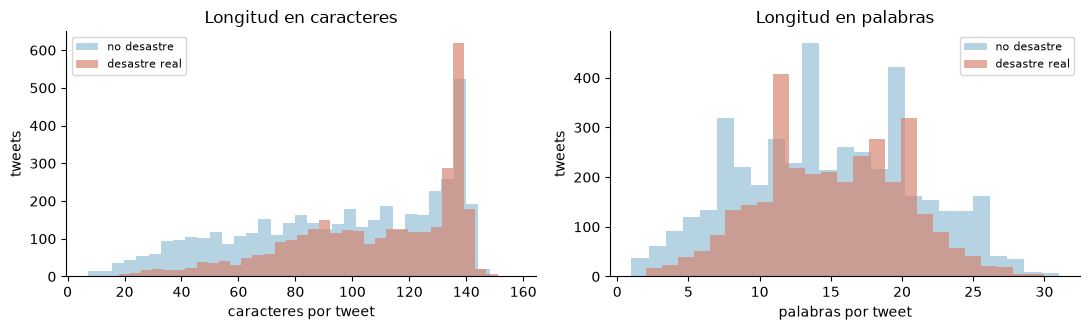

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for valor, color, etiqueta in [("0", "#8fbcd4", "no desastre"), ("1", "#d47f6a", "desastre real")]:
    sub = df[df["target"] == valor]
    axes[0].hist(sub["n_caracteres"], bins=35, alpha=0.65, color=color, label=etiqueta)
    axes[1].hist(sub["n_palabras"], bins=25, alpha=0.65, color=color, label=etiqueta)
axes[0].set_xlabel("caracteres por tweet"); axes[0].set_title("Longitud en caracteres")
axes[1].set_xlabel("palabras por tweet");   axes[1].set_title("Longitud en palabras")
for a in axes:
    a.set_ylabel("tweets"); a.legend(fontsize=8); a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

Los tweets de desastre real son sistemáticamente más largos, 108 contra 96 caracteres de media, y traen URL
con mucha más frecuencia, 66% contra 41%. El contraste más fuerte está en la dirección inversa, ya que entre
los tweets sin URL solo el 30% son desastres reales.

Considero que tiene sentido, pues un desastre real se reporta enlazando una nota de prensa, mientras que el
uso metafórico (*"this party is fire"*) suele ser texto suelto. Lo mismo pasa con las menciones `@`, que son
más comunes en conversación casual, 0.42 contra 0.27 por tweet.

Dicho esto, acá aparece el matiz más delicado del notebook. El enunciado manda quitar URLs y menciones, y hay
que hacerlo porque una URL de `t.co` es una cadena aleatoria que no aporta nada como token. Sin embargo, el
hecho de que el tweet trajera una URL sí es informativo, es por esto que no se borran a secas: primero se
registran como variables binarias o de conteo, y después se elimina el texto. En otras palabras, se elimina
la cadena pero se conserva la señal.

---

# **3. Acciones de limpieza y preprocesamiento a ejecutar**

Cada acción indica por qué se hace y qué celda de este notebook la respalda.

### **A. Correcciones de integridad, antes de tocar el texto**

- **Decodificar el mojibake** de `text`, es decir revertir `\x89Û_`, `\x89Ûª`, `\x89ÛÏ` y `\x89ÛÒ` a su
  carácter original, o bien eliminarlos. Afecta al 8.07% de los tweets y parte palabras en dos si no se trata.
  *(§2.4, mojibake)*
- **Decodificar las entidades HTML** (`&amp;` a `&`, `&lt;` a `<`, `&gt;` a `>`). Afecta al 4.72%. *(§2.4)*
- **Decodificar el `%20` de `keyword`**, de tal forma que `airplane%20accident` quede como
  `airplane accident`. Afecta a 1,165 filas. *(§2.2)*
- **Eliminar los 18 textos con etiquetas contradictorias**, ya que no se puede saber cuál etiqueta es la
  correcta y elegir una al azar sería meter ruido a propósito. *(§2.5)*
- **Deduplicar los 110 textos repetidos**, conservando una sola ocurrencia, para poder evitar la fuga de
  datos entre entrenamiento y prueba. *(§2.5)*
- **Normalizar las variantes de 911** (`911`, `9/11`, `9-11`, `WTC`) a un token único e irrompible, antes de
  quitar la puntuación. Si se hace después ya no existen. *(§2.4, números y 911)*
- **Tipar las variables:** `target` e `id` a entero, `keyword` a categoría. *(§1)*

### **B. Extracción de la señal antes de destruirla**

- **`tiene_url`** (binaria): entre los tweets sin URL solo el 30% son desastre real, contra un 55% entre los
  que sí la traen, de tal forma que es la señal auxiliar más fuerte que se encontró. 
- **`n_hashtags` y `n_menciones`** (conteos), dado que las menciones son más frecuentes en tweets casuales.
- **`n_caracteres` y `n_palabras`** (conteos), pues los tweets de desastre son alrededor de 12 caracteres más
  largos.
- **`n_mayusculas`** (conteo de palabras en mayúscula): el 19.5% de los tweets tiene alguna, y el paso de
  minúsculas la borra, una persona usualmente se expresa en mayúsculas si es algo relevante, o para indicar emergencia.

### **C. Normalización del texto**

- **Eliminar las URLs** (`https?://\S+`). Afecta al 52.16%. Una URL de `t.co` es una cadena aleatoria, de tal
  forma que como token es única e inútil, y adicional, su presencia ya quedó guardada en `tiene_url`.
- **Eliminar el `@` de las menciones**, descartando el nombre de usuario. Afecta al 26.39%. Los handles son
  identificadores y no vocabulario.
- **Quitar el `#` de los hashtags pero conservar la palabra**, de tal forma que `#earthquake` quede como
  `earthquake`. Afecta al 22.90%. Es el único símbolo que no se borra junto con su contenido, ya que el
  hashtag suele ser el término más informativo del tweet. 
- **Eliminar el prefijo `RT`** de los retweets (0.59%).
- **Convertir todo a minúsculas** para poder unificar `Fire`, `fire` y `FIRE` en un solo token. Se hace
  después de contar las mayúsculas.
- **Tratar los apóstrofes antes de tokenizar**, ya sea expandiendo las contracciones (`don't` a `do not`) o
  uniéndolas (`don't` a `dont`). Afecta al 26.01%, y sin esto aparece el token basura `s`.
- **Eliminar los signos de puntuación.** Afecta al 95.59%. 
- **Eliminar los saltos de línea** y colapsar los espacios múltiples. Afecta al 5.71%. 
- **Eliminar los caracteres no ASCII restantes** después de corregir el mojibake.

### **D. Tokenización**

- **Eliminar todos los dígitos y tokens numéricos, salvo el `emergencia911`** ya normalizado en el bloque A.
  El 59.44% de los tweets tiene dígitos, y los más frecuentes son fragmentos de fecha y dígitos sueltos.
- **Eliminar las stopwords** en inglés, ya que las 15 palabras más frecuentes son todas stopwords y concentran
  cerca del 20% de los tokens. Sin quitarlas, la nube de palabras del ejercicio 5 solo mostraría artículos.
- **Eliminar los tokens de 1 o 2 caracteres** que queden como residuo del proceso.
- **Aplicar lematización o stemming** para poder unificar `fires`, `fire` y `burning`. Se decidirá comparando
  ambas en el ejercicio 4.

### **E. Dos versiones del texto, no una**

Esta es la consecuencia de todo lo anterior, y es que el preprocesamiento agresivo que necesita el
clasificador destruye lo que el análisis de sentimiento necesita leer, o sea las negaciones, la intensidad y
los signos. Es por esto que el pipeline produce dos columnas:

- **`texto_limpio`**, con todo el bloque C y E aplicado, que alimenta los n-gramas del ejercicio 4 y los
  modelos del ejercicio 6.
- **`texto_sentimiento`**, con el bloque A más la eliminación de URLs y menciones, conservando la puntuación,
  las mayúsculas y las negaciones, que alimenta el análisis de sentimiento del ejercicio 8.

---
